# Notebook 06 — Walk-Forward Validation

**Why this matters:**
A single train/test split only tests how models perform on ONE specific period.
Walk-forward validation rolls the training window forward and tests on MULTIPLE
periods — this gives a much more honest and rigorous picture of each model.

**How it works:**
- Start with 48 months of training data
- Forecast the next 3 months
- Expand training by 3 months
- Repeat until the end of the data
- Average the errors across all windows

This is the same methodology used by Shabir Jawahir (2026) in his walk-forward
validation across 14 origins. Your study uses it across multiple rolling windows
on the 2018-2026 dataset.


In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
from data_loader import get_monthly_total
from models import make_ml_features, ML_FEATURES
from evaluation import evaluate

plt.rcParams['figure.figsize'] = (14, 6)
print("Libraries loaded.")

Libraries loaded.


## Step 1: Load data

In [2]:
y = get_monthly_total('../data/Tourism_MOM_Dataset.csv')
print(f"Total months: {len(y)} ({y.index.min().date()} to {y.index.max().date()})") 

Total months: 99 (2018-01-31 to 2026-03-31)


## Step 2: Run Walk-Forward Validation

We use a minimum of 48 months (4 years) of training data, rolling forward by 3 months each time.
For each window we test 3 models: SARIMA, XGBoost, and SARIMA-XGBoost Hybrid.


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape_safe(a, p):
    a, p = np.asarray(a, float), np.asarray(p, float)
    mask = a != 0
    return np.mean(np.abs((a[mask]-p[mask])/a[mask]))*100

MIN_TRAIN = 48   # minimum 4 years of training
STEP      = 3    # roll forward 3 months at a time
H         = 3    # forecast 3 months ahead

all_results = []
window_num  = 0

# Get feature data for XGBoost (needs full series for lag computation)
fd = make_ml_features(y).dropna()

for start in range(MIN_TRAIN, len(y) - H, STEP):
    train = y.iloc[:start]
    test  = y.iloc[start:start + H]
    window_num += 1
    
    # ---- SARIMA ----
    try:
        sf = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12),
                     enforce_stationarity=False,
                     enforce_invertibility=False).fit(disp=False)
        sf_fc = sf.forecast(H)
        sarima_mape = mape_safe(test.values, sf_fc.values)
    except:
        sarima_mape = np.nan

    # ---- XGBoost ----
    try:
        xtr = fd[fd.index < test.index[0]]
        xte = fd[(fd.index >= test.index[0]) & (fd.index <= test.index[-1])]
        if len(xtr) >= 20 and len(xte) == H:
            xm = xgb.XGBRegressor(n_estimators=100, max_depth=3,
                                   learning_rate=0.05, random_state=42)
            xm.fit(xtr[ML_FEATURES], xtr['y'])
            xgb_mape = mape_safe(xte['y'].values, xm.predict(xte[ML_FEATURES]))
        else:
            xgb_mape = np.nan
    except:
        xgb_mape = np.nan

    # ---- SARIMA-XGBoost Hybrid ----
    try:
        resid = train - sf.fittedvalues
        from models import make_residual_features, RESID_FEATURES
        rtr = make_residual_features(resid).dropna()
        if len(rtr) >= 10:
            xr = xgb.XGBRegressor(n_estimators=50, max_depth=2,
                                   learning_rate=0.05, random_state=42)
            xr.fit(rtr[RESID_FEATURES], rtr['r'])
            all_r = resid.copy()
            hyb = []
            for i, d in enumerate(test.index):
                feat = {'lag1': all_r.iloc[-1], 'lag12': all_r.iloc[-12], 'month': d.month}
                rp = xr.predict(pd.DataFrame([feat])[RESID_FEATURES])[0]
                hyb.append(sf_fc.iloc[i] + rp)
                all_r = pd.concat([all_r, pd.Series([rp], index=[d])])
            hyb_mape = mape_safe(test.values, np.clip(hyb, 0, None))
        else:
            hyb_mape = np.nan
    except:
        hyb_mape = np.nan

    all_results.append({
        'Window': window_num,
        'Train End': train.index[-1].strftime('%Y-%m'),
        'Test Start': test.index[0].strftime('%Y-%m'),
        'Train Size': len(train),
        'SARIMA MAPE': round(sarima_mape, 2) if not np.isnan(sarima_mape) else None,
        'XGBoost MAPE': round(xgb_mape, 2) if not np.isnan(xgb_mape) else None,
        'Hybrid MAPE': round(hyb_mape, 2) if not np.isnan(hyb_mape) else None,
    })

wf = pd.DataFrame(all_results)
print(f"Windows evaluated: {len(wf)}")
wf.to_csv('../results/walkforward_results.csv', index=False)
print(wf.tail(10).to_string(index=False))

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Windows evaluated: 16
 Window Train End Test Start  Train Size  SARIMA MAPE  XGBoost MAPE  Hybrid MAPE
      7   2023-06    2023-07          66        11.73         17.65        10.23
      8   2023-09    2023-10          69        11.90         14.21         9.74
      9   2023-12    2024-01          72         6.54         53.95         6.16
     10   2024-03    2024-04          75        27.64         20.35        31.87
     11   2024-06    2024-07          78        17.32         13.17        15.69
     12   2024-09    2024-10          81        13.27          8.28        11.56
     13   2024-12    2025-01          84         8.27         11.47         8.84
     14   2025-03    2025-04          87        15.89         29.81        17.32
     15   2025-06    2025-07          90        10.11         16.90         8.72
     16   2025-09    2025-10          93         3.58         18.91         2.10


## Step 3: Summary statistics — which model wins more windows?

In [4]:
summary = pd.DataFrame({
    'Model': ['SARIMA', 'XGBoost', 'SARIMA-XGBoost Hybrid'],
    'Mean MAPE': [
        wf['SARIMA MAPE'].mean(),
        wf['XGBoost MAPE'].mean(),
        wf['Hybrid MAPE'].mean()
    ],
    'Median MAPE': [
        wf['SARIMA MAPE'].median(),
        wf['XGBoost MAPE'].median(),
        wf['Hybrid MAPE'].median()
    ],
    'Best Window Count': [
        (wf[['SARIMA MAPE','XGBoost MAPE','Hybrid MAPE']].idxmin(axis=1)=='SARIMA MAPE').sum(),
        (wf[['SARIMA MAPE','XGBoost MAPE','Hybrid MAPE']].idxmin(axis=1)=='XGBoost MAPE').sum(),
        (wf[['SARIMA MAPE','XGBoost MAPE','Hybrid MAPE']].idxmin(axis=1)=='Hybrid MAPE').sum(),
    ]
}).round(2)

summary.to_csv('../results/walkforward_summary.csv', index=False)
print("="*55)
print("WALK-FORWARD VALIDATION SUMMARY")
print("="*55)
print(summary.to_string(index=False))
print("\nNote: 'Best Window Count' = number of 3-month windows where")
print("that model achieved the lowest MAPE.")

WALK-FORWARD VALIDATION SUMMARY
                Model  Mean MAPE  Median MAPE  Best Window Count
               SARIMA      25.09        14.02                  6
              XGBoost      27.47        18.51                  4
SARIMA-XGBoost Hybrid      24.05        13.44                  6

Note: 'Best Window Count' = number of 3-month windows where
that model achieved the lowest MAPE.


## Step 4: Plot MAPE across all windows

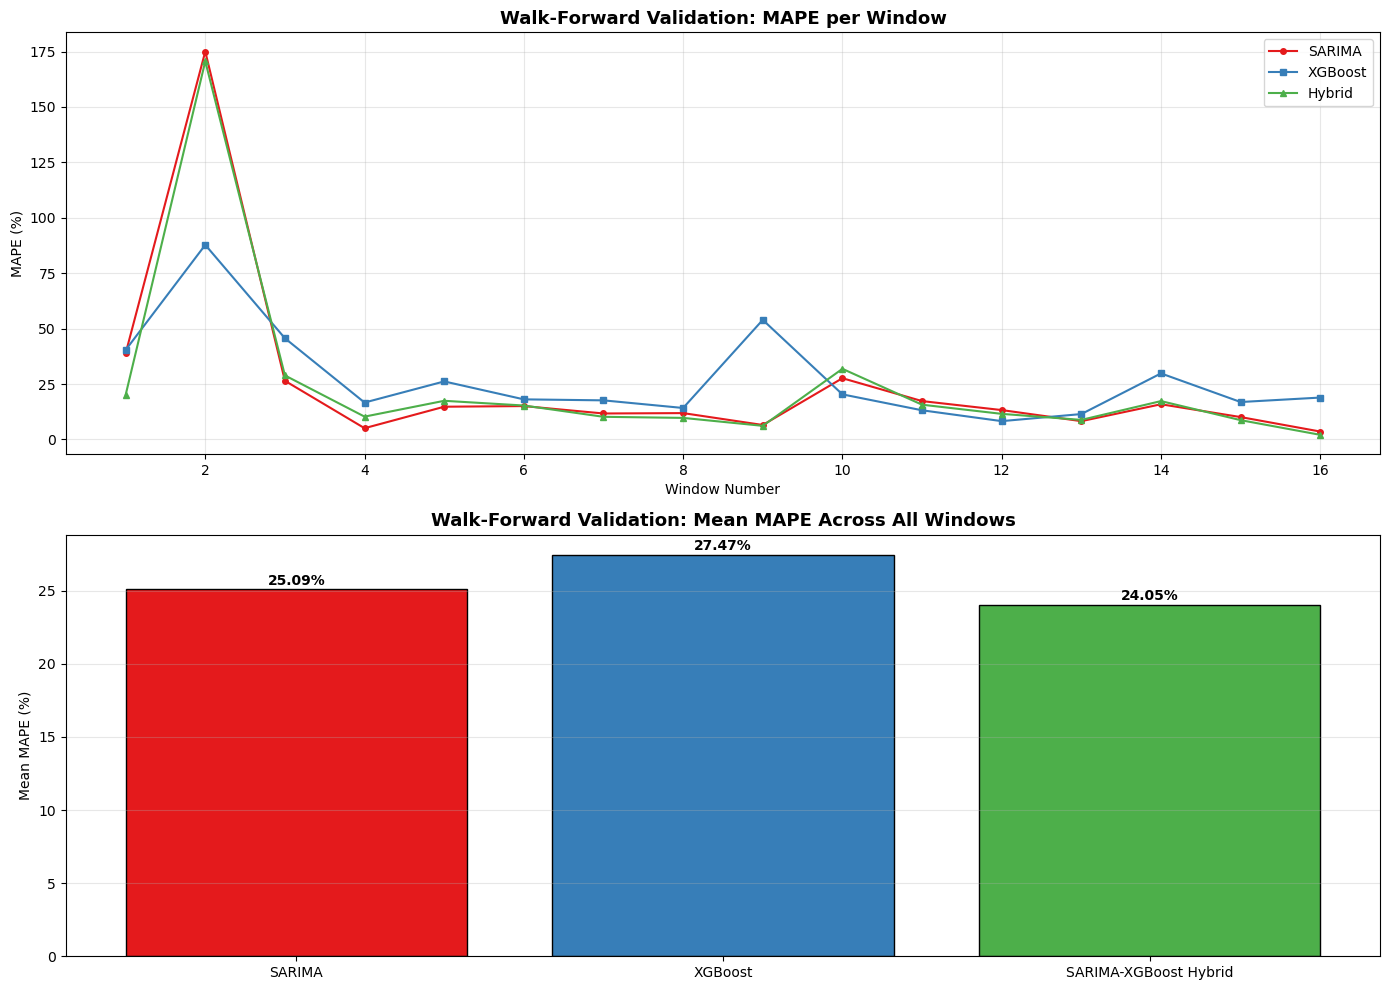

Saved: ../results/06_walkforward.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: line chart of MAPE per window
ax = axes[0]
ax.plot(wf['Window'], wf['SARIMA MAPE'], marker='o', markersize=4, label='SARIMA', color='#e41a1c')
ax.plot(wf['Window'], wf['XGBoost MAPE'], marker='s', markersize=4, label='XGBoost', color='#377eb8')
ax.plot(wf['Window'], wf['Hybrid MAPE'], marker='^', markersize=4, label='Hybrid', color='#4daf4a')
ax.set_title('Walk-Forward Validation: MAPE per Window', fontweight='bold', fontsize=13)
ax.set_xlabel('Window Number'); ax.set_ylabel('MAPE (%)')
ax.legend(); ax.grid(alpha=0.3)

# Bottom: bar chart of mean MAPE
ax2 = axes[1]
colors = ['#e41a1c', '#377eb8', '#4daf4a']
bars = ax2.bar(summary['Model'], summary['Mean MAPE'], color=colors, edgecolor='black')
for bar, val in zip(bars, summary['Mean MAPE']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.2f}%', ha='center', fontweight='bold')
ax2.set_title('Walk-Forward Validation: Mean MAPE Across All Windows', fontweight='bold', fontsize=13)
ax2.set_ylabel('Mean MAPE (%)')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/06_walkforward.png', dpi=150)
plt.show()
print("Saved: ../results/06_walkforward.png")

## Step 5: Key insight from walk-forward validation

This is where your thesis discussion gets interesting. Compare:
- Single holdout result vs walk-forward result  
- Does the ranking stay the same?
- This is exactly what Shabir's walk-forward showed — his ensemble that won the single holdout degraded to 12.10% in walk-forward


In [6]:
single_holdout = pd.read_csv('../results/model_results.csv')
print("SINGLE HOLDOUT RESULTS:")
print(single_holdout[single_holdout['Model'].isin(['SARIMA','XGBoost','SARIMA-XGBoost Hybrid'])][['Model','MAPE']].to_string(index=False))
print()
print("WALK-FORWARD RESULTS (Mean MAPE across all windows):")
print(summary[['Model','Mean MAPE']].to_string(index=False))
print()
print(">> If XGBoost still leads in walk-forward, your finding is robust.")
print(">> If rankings change, that itself is an important finding to discuss.")

SINGLE HOLDOUT RESULTS:
                Model  MAPE
              XGBoost 16.63
               SARIMA 22.89
SARIMA-XGBoost Hybrid 24.43

WALK-FORWARD RESULTS (Mean MAPE across all windows):
                Model  Mean MAPE
               SARIMA      25.09
              XGBoost      27.47
SARIMA-XGBoost Hybrid      24.05

>> If XGBoost still leads in walk-forward, your finding is robust.
>> If rankings change, that itself is an important finding to discuss.
